In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv("/Titanic-Dataset.csv")
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [12]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [14]:
df["Age"].fillna(df["Age"].mean(), inplace=True)
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

if "Cabin" in df.columns:
    df.drop(columns=["Cabin"], inplace=True)

print("Cleaning completed")

Cleaning completed


/tmp/ipykernel_9015/2289986177.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].mean(), inplace=True)
/tmp/ipykernel_9015/2289986177.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [16]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0,12,18,30,50,80],
    labels=["Child","Teen","YoungAdult","Adult","Senior"]
)

print(df[["Age","AgeGroup"]].head())

    Age    AgeGroup
0  22.0  YoungAdult
1  38.0       Adult
2  26.0  YoungAdult
3  35.0       Adult
4  35.0       Adult


In [18]:
df["FamilySize"] = df["SibSp"] + df["Parch"]

print(df[["SibSp","Parch","FamilySize"]].head())

   SibSp  Parch  FamilySize
0      1      0           1
1      1      0           1
2      0      0           0
3      1      0           1
4      0      0           0


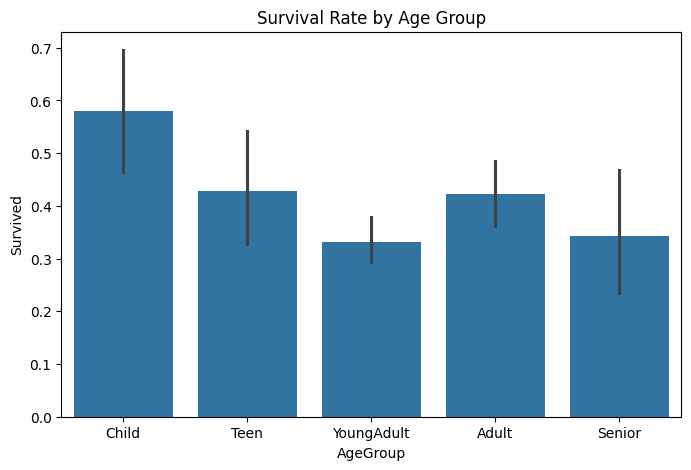

In [20]:
plt.figure(figsize=(8,5))
sns.barplot(x="AgeGroup", y="Survived", data=df)
plt.title("Survival Rate by Age Group")
plt.show()

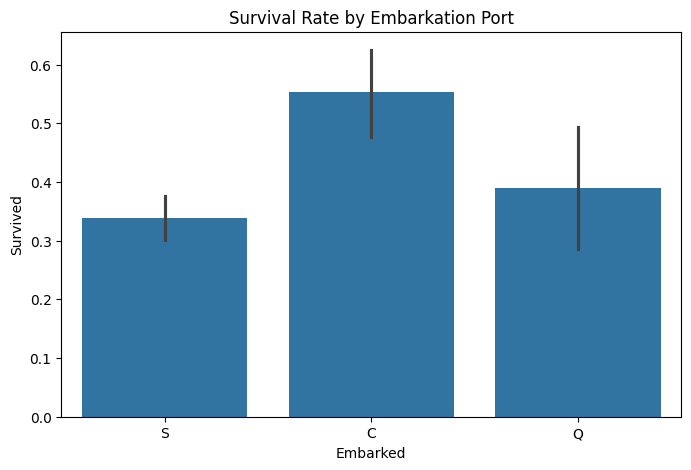

In [22]:
plt.figure(figsize=(8,5))
sns.barplot(x="Embarked", y="Survived", data=df)
plt.title("Survival Rate by Embarkation Port")
plt.show()

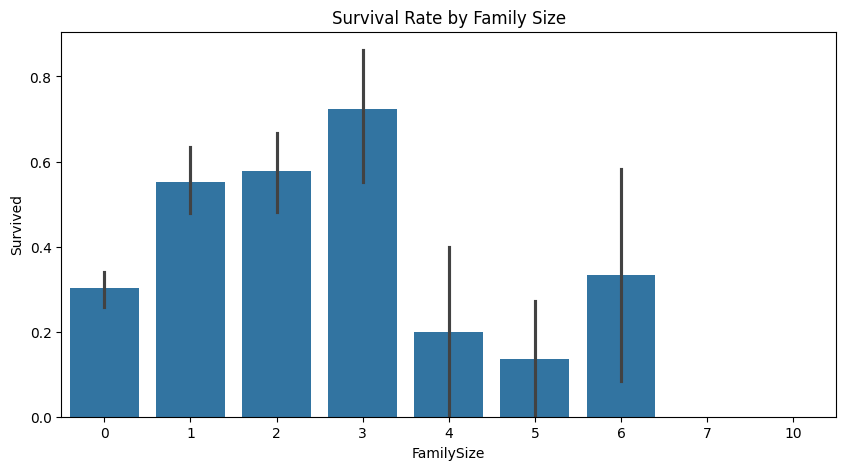

In [24]:
plt.figure(figsize=(10,5))
sns.barplot(x="FamilySize", y="Survived", data=df)
plt.title("Survival Rate by Family Size")
plt.show()

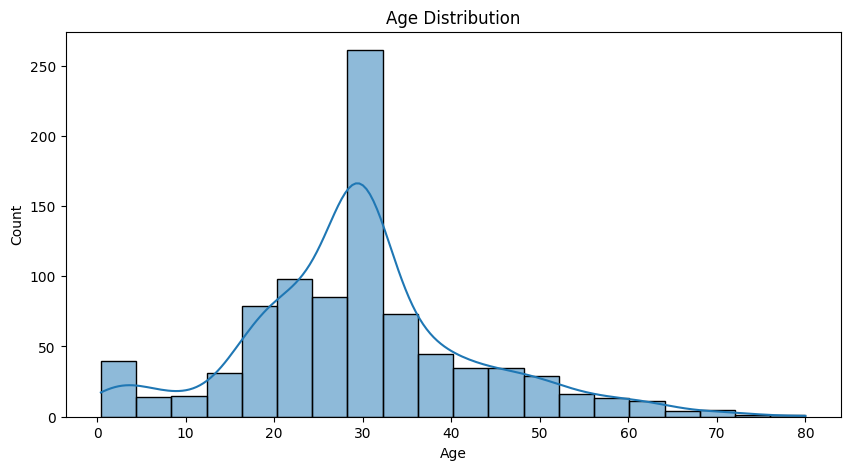

In [26]:
plt.figure(figsize=(10,5))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

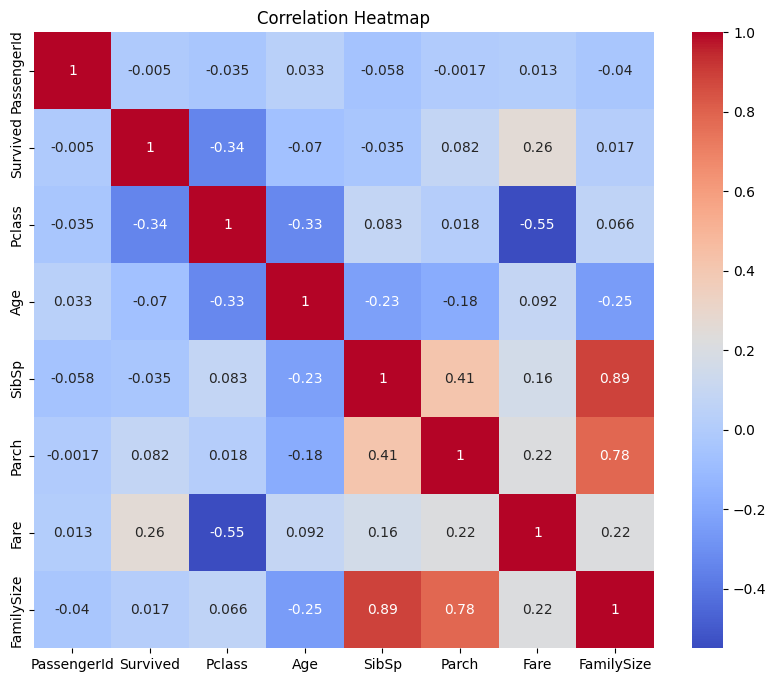

In [28]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [30]:
print("Average Age:", df["Age"].mean())
print("Average Survival Rate:", df["Survived"].mean())
print("Most Common Embarkation Port:", df["Embarked"].mode()[0])

Average Age: 29.69911764705882
Average Survival Rate: 0.3838383838383838
Most Common Embarkation Port: S
